# Puzzle Velocity Analysis — Day Three

*Same question as [day one](puzzle_velocity_analysis.ipynb) and
[day two](day-two-analysis.ipynb): is the lccjs microtask estimator any good, and
what can we trust about it?* This is a third cut on a now-larger
`docs/puzzle-velocity.csv`. Two things changed since day two that open **new** axes:

1. **A third working day** of data exists (05-28, 05-29, **05-30**). Day two could
   only bucket into two days and called a calibration-over-time trend *"forming."*
   Three points is still thin, but it's the first time the question is even askable.
2. The **`agent` column is now populated** across a fleet of four (APPLE, BANANA,
   CHERRY, DRAGONFRUIT). That lets us ask whether the over-padding is a property of
   *the workflow* or differs *by agent* — gated, of course, on per-agent `n`.

This pass also surfaced a **data-quality bug** in the shared CSV (§0) that we handle
**in-memory** — the committed file is left untouched. Everything is gated against the
noise floor exactly as before; new sections are marked 🆕 and carried-over findings
are stated briefly, not re-derived from scratch.

In [1]:
import csv, io, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

RAW = Path("../docs/puzzle-velocity.csv")  # notebook runs from stats/
raw_lines = RAW.read_text().splitlines(keepends=True)
NH = len(next(csv.reader([raw_lines[0]])))

def n_fields(line):
    return len(next(csv.reader([line])))

# Three rows (APPLE's #157 x2 + #271) were appended with BACKSLASH escaping
# (\\" , \\\\) where CSV wants DOUBLED quotes ("") — invalid CSV that crashes
# stats/enrich.py and mis-parses under pandas. Repair the offending lines
# IN MEMORY only; the committed CSV is never modified here.
def repair(line):
    return line.replace("\\\\", "\\").replace('\\"', '""')

repaired, n_fixed = [], 0
for i, ln in enumerate(raw_lines):
    if i > 0 and n_fields(ln) != NH:
        ln = repair(ln); n_fixed += 1
    repaired.append(ln)

df = pd.read_csv(io.StringIO("".join(repaired)))

for c in ["h_min", "c_min", "actual_min"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop exact-signature accidental double-logs (same ticket/role/timestamps/estimates,
# differing only in the free-text notes) — keep the LAST (the corrected re-add).
# This removes APPLE's #157 duplicate without touching legitimate multi-row tickets
# (e.g. #259 = a PM-filing row AND a DEV-fix row are DIFFERENT work units, kept).
sig = [c for c in df.columns if c != "notes"]
before = len(df)
df = df.drop_duplicates(subset=sig, keep="last").reset_index(drop=True)
n_dup = before - len(df)

df["c_ratio"] = df["c_min"] / df["actual_min"]
df["finished"] = pd.to_datetime(df["finished_iso"], errors="coerce", utc=True)
df["hst_day"]  = df["finished"].dt.tz_convert("Etc/GMT+10").dt.date  # HST = UTC-10, project tz
df["agent"] = df["agent"].fillna("").astype(str).str.strip()
df["role"]  = df["role"].fillna("").astype(str).str.strip()

print("DATA HYGIENE (day-3 in-memory loader)")
print(f"  malformed rows repaired in memory .. {n_fixed}   (backslash-escaped notes -> CSV quote-doubling)")
print(f"  exact-duplicate rows dropped ....... {n_dup}   (kept the corrected re-add)")
print(f"  committed docs/puzzle-velocity.csv . UNTOUCHED (repair is in-memory only)")


DATA HYGIENE (day-3 in-memory loader)
  malformed rows repaired in memory .. 3   (backslash-escaped notes -> CSV quote-doubling)
  exact-duplicate rows dropped ....... 1   (kept the corrected re-add)
  committed docs/puzzle-velocity.csv . UNTOUCHED (repair is in-memory only)


## 0. Data provenance, noise floor, and the corruption that surfaced this pass

Before any conclusion: how much did the dataset grow, how does it split by day /
agent / role, and what was wrong with it. Every later section is gated against
these counts — a bigger `n` only helps a claim if the rows it adds are relevant.

**The data-quality finding.** Three rows (APPLE's `#157` ×2 and `#271`) were
appended with shell/JSON-style backslash escaping (`\"`, `\\n`) instead of CSV
quote-doubling (`""`). That is invalid CSV: it crashes `stats/enrich.py`
(`dict contains fields not in fieldnames: None`) and mis-parses under pandas. One of
the `#157` rows is also an **accidental duplicate** (identical role + timestamps +
estimates, only the notes differ — the pre-`#271` wording that `#271` later
corrected). The loader above repairs both **in memory** so this analysis can run; the
committed file is deliberately left untouched (a destructive rewrite of another
agent's rows isn't this notebook's job). The real fix belongs at the *source* — see
§5.

In [2]:
cal = df[df["c_ratio"].notna() & (df["actual_min"] > 0)].copy()

print("DATASET SCOPE (day three)")
print(f"  rows total ...................... {len(df)}")
print(f"  calibration rows (C & actual) ... {len(cal)}")
print(f"  finished span ................... {df['finished'].min()}  ->  {df['finished'].max()}")

print("\n  calibration rows per HST working day:")
print(cal.groupby("hst_day").size().to_string())

print("\n  calibration rows per agent (blank = pre-#180 / unattributed):")
print(cal.assign(agent=cal["agent"].replace("", "(none)")).groupby("agent").size().to_string())

print("\n  calibration rows per role:")
print(cal.groupby("role").size().sort_values(ascending=False).to_string())


DATASET SCOPE (day three)
  rows total ...................... 124
  calibration rows (C & actual) ... 105
  finished span ................... 2026-05-28 21:58:35+00:00  ->  2026-05-31 04:29:29+00:00

  calibration rows per HST working day:
hst_day
2026-05-28    36
2026-05-29    32
2026-05-30    37

  calibration rows per agent (blank = pre-#180 / unattributed):
agent
(none)         39
APPLE          24
BANANA         22
CHERRY         11
DRAGONFRUIT     9

  calibration rows per role:
role
DEV         29
WRITER      27
TEST        15
RESEARCH    13
ARC          5
PM           5
COMBO        4
SPIKE        4
DATA         3


## 1. 🆕 Calibration across three days — is the over-pad shrinking?

Day one couldn't ask this (one session). Day two had two day-buckets and called the
trend *"forming."* Now there are three HST working days. We compute the **median
C-ratio per day** with a bootstrap CI (gating each day at n≥5), and run a
**Spearman** rank-correlation of `c_ratio` against day-index across the gated rows.
Three points is still weak — so we report **direction + CI**, not a slope we'd
defend. A C-ratio of 1.0 is perfect; >1 is over-padding.

Per-day median C-ratio (days with n>=5):
       day  n  median_cratio       lo       hi
2026-05-28 36       2.511948 2.209945 3.000000
2026-05-29 32       5.000000 3.000000 6.875000
2026-05-30 37       3.461538 2.777778 4.422604

Spearman(day-index, c_ratio): rho=+0.175, p=0.074  (n=105 rows, 3 days)


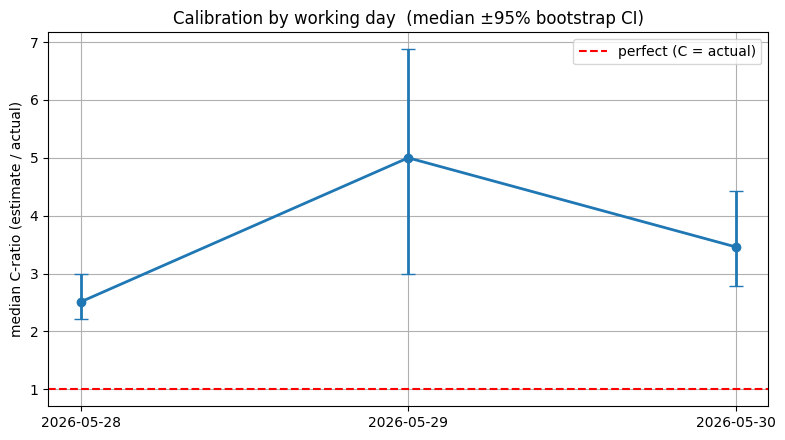

In [3]:
rows = []
for d, g in cal.groupby("hst_day"):
    r = g["c_ratio"].values
    if len(r) >= 5:
        b = np.array([np.median(rng.choice(r, len(r), replace=True)) for _ in range(5000)])
        lo, hi = np.percentile(b, [2.5, 97.5])
        rows.append((d, len(r), float(np.median(r)), lo, hi))
ds = pd.DataFrame(rows, columns=["day", "n", "median_cratio", "lo", "hi"])
print("Per-day median C-ratio (days with n>=5):")
print(ds.to_string(index=False))

gated_days = sorted(ds["day"].tolist())
sub = cal[cal["hst_day"].isin(gated_days)].copy()
didx = {d: i for i, d in enumerate(gated_days)}
sub["di"] = sub["hst_day"].map(didx)
if sub["di"].nunique() >= 2:
    rho, p = stats.spearmanr(sub["di"], sub["c_ratio"])
    print(f"\nSpearman(day-index, c_ratio): rho={rho:+.3f}, p={p:.3f}  (n={len(sub)} rows, {len(gated_days)} days)")

if len(ds) >= 1:
    plt.errorbar(range(len(ds)), ds["median_cratio"],
                 yerr=[ds["median_cratio"] - ds["lo"], ds["hi"] - ds["median_cratio"]],
                 fmt="o-", capsize=5, lw=2)
    plt.axhline(1.0, color="r", ls="--", label="perfect (C = actual)")
    plt.xticks(range(len(ds)), [str(d) for d in ds["day"]])
    plt.ylabel("median C-ratio (estimate / actual)")
    plt.title("Calibration by working day  (median ±95% bootstrap CI)")
    plt.legend(); plt.tight_layout(); plt.show()


**Read — no, the over-pad is not shrinking.** The three per-day medians are
**2.5× → 5.0× → 3.5×** (05-28 → 05-29 → 05-30): *non-monotone*, with 05-29 the
**most** over-padded day, not the least. The Spearman rank test is positive and
not significant (ρ = +0.18, p = 0.07) — if anything the estimate drifted slightly
*up*, but with three day-buckets and overlapping bootstrap CIs (especially 05-29's
wide [3.0×, 6.9×]) there is no trend either way. **Honest call: calibration is flat
across the three days — no learning curve is visible yet, and a
monotone-improvement story is not supported.** 05-29 standing out is more likely a
task-mix artifact (see §2's role-mix confound) than a genuinely worse day.

## 2. 🆕 Per-agent calibration — workflow property or agent property?

The fleet now has four agents. Is the over-padding uniform (a property of the
*estimation habit the workflow trains*) or does it vary by agent? We show each
agent's `n`, median C-ratio, IQR, and **role mix** (a key confounder — agents don't
draw the same task types), gate at n≥5, and run a non-parametric **Kruskal-Wallis**
across the gated agents. With four small samples this is a screen, not a verdict.

      agent  n  median_cratio      q25      q75                                                            role_mix
     CHERRY 11       2.343750 1.421013 2.802198         RESEARCH:3, PM:2, DEV:2, WRITER:1, COMBO:1, TEST:1, SPIKE:1
DRAGONFRUIT  9       2.777778 2.068966 4.571429                          DATA:2, WRITER:2, DEV:2, RESEARCH:2, ARC:1
     BANANA 22       3.222683 2.051471 4.618532 TEST:7, DEV:5, RESEARCH:3, WRITER:2, PM:2, SPIKE:1, COMBO:1, DATA:1
      APPLE 24       5.333460 3.663020 7.500000         TEST:6, WRITER:5, RESEARCH:5, DEV:4, SPIKE:2, COMBO:1, PM:1

agents clearing n>=5: ['APPLE', 'BANANA', 'CHERRY', 'DRAGONFRUIT']
Kruskal-Wallis across 4 agents: H=21.34, p=0.000  ->  some evidence of a per-agent difference


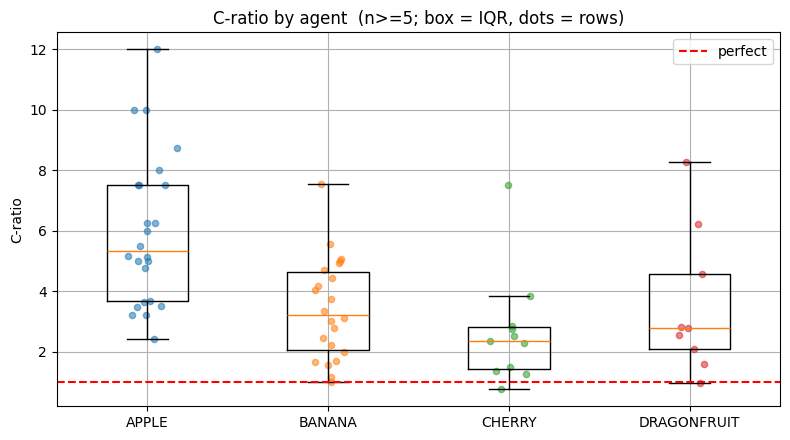

In [4]:
ag = cal[cal["agent"] != ""].copy()
rows = []
for a, g in ag.groupby("agent"):
    mix = ", ".join(f"{k}:{v}" for k, v in g["role"].value_counts().items())
    rows.append((a, len(g), float(g["c_ratio"].median()),
                 float(g["c_ratio"].quantile(.25)), float(g["c_ratio"].quantile(.75)), mix))
at = (pd.DataFrame(rows, columns=["agent", "n", "median_cratio", "q25", "q75", "role_mix"])
        .sort_values("median_cratio").reset_index(drop=True))
print(at.to_string(index=False))

gated = sorted([a for a, g in ag.groupby("agent") if len(g) >= 5])
print(f"\nagents clearing n>=5: {gated}")
if len(gated) >= 2:
    samples = [ag.loc[ag["agent"] == a, "c_ratio"].values for a in gated]
    H, p = stats.kruskal(*samples)
    verdict = "NO evidence" if p >= 0.05 else "some evidence"
    print(f"Kruskal-Wallis across {len(gated)} agents: H={H:.2f}, p={p:.3f}  ->  {verdict} of a per-agent difference")
else:
    print("fewer than 2 agents clear the gate -> NOT EVALUATED")

if gated:
    data = [ag.loc[ag["agent"] == a, "c_ratio"].values for a in gated]
    plt.boxplot(data, showfliers=False)
    for i, a in enumerate(gated, 1):
        y = ag.loc[ag["agent"] == a, "c_ratio"].values
        x = np.full(len(y), i) + rng.normal(0, 0.06, len(y))
        plt.scatter(x, y, alpha=0.55, s=20)
    plt.xticks(range(1, len(gated) + 1), gated)
    plt.axhline(1.0, color="r", ls="--", label="perfect")
    plt.ylabel("C-ratio"); plt.title("C-ratio by agent  (n>=5; box = IQR, dots = rows)")
    plt.legend(); plt.tight_layout(); plt.show()


**Read — the agents differ, but it's a task-mix confound, not a skill ranking.**
Measured over-padding runs CHERRY ≈ 2.3× · DRAGONFRUIT ≈ 2.8× · BANANA ≈ 3.2× ·
APPLE ≈ 5.3×, and the Kruskal-Wallis screen *is* significant (H = 21.3, p < 0.001).
But the `role_mix` column shows why to distrust the ranking: APPLE (top of the
table) carries the heaviest RESEARCH / SPIKE / WRITER load, and day one's §6 already
found **research/spike tasks are the most over-padded** (you pad for unknowns that
evaporate once context warms). So the *agent* axis is entangled with the *task-type*
axis — and probably with the *day* axis too (05-29 was both high-pad and
research-heavy). Disentangling needs a two-way agent × role cut, which is
**underpowered** at these per-cell counts. Read this as: *there is real spread in
calibration across the fleet, and it tracks the kind of work each agent drew* — not
"CHERRY estimates better than APPLE.\"

## 3. The robust finding holds — the estimator is biased high

Carried over from days one and two, re-run on the larger cleaned calibration set.
The *direction* is the trustworthy part: a binary over/under **sign test** (makes no
assumption about the noisy ratio magnitudes), plus a bootstrap CI on the median
C-ratio.

In [5]:
n = len(cal)
n_over = int((cal["c_ratio"] > 1).sum())
bt = stats.binomtest(n_over, n, 0.5, alternative="greater")
print(f"calibration rows ............ {n}")
print(f"finished faster than C est .. {n_over}  ({n_over/n:.0%})")
print(f"sign test p ................. {bt.pvalue:.2e}")

lr = np.log(cal["c_ratio"].values)
boot = np.array([np.median(rng.choice(lr, len(lr), replace=True)) for _ in range(5000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"\nmedian C-ratio = {np.median(cal['c_ratio']):.2f}x")
print(f"95% CI on median (back-transformed) = [{np.exp(lo):.2f}x, {np.exp(hi):.2f}x]  (excludes 1.0 => bias is real)")
print(f"mean C-ratio = {cal['c_ratio'].mean():.2f}x  (outlier-driven; reported only to show why we use the median)")


calibration rows ............ 105
finished faster than C est .. 100  (95%)
sign test p ................. 2.50e-24



median C-ratio = 3.21x
95% CI on median (back-transformed) = [2.76x, 3.75x]  (excludes 1.0 => bias is real)
mean C-ratio = 3.92x  (outlier-driven; reported only to show why we use the median)


**Read — overwhelming, and only sharper with more data.** **100 of 105**
calibration tasks finished faster than their C-estimate (sign test p ≈ 2.5e-24),
and the bootstrap CI on the median C-ratio (**2.76×–3.75×**) sits far above the 1.0×
break-even. The estimator is **systematically biased high by roughly 3×**; three
days of accumulation have not moved that. The mean (3.92×) runs above the median
because a few tiny-denominator rows dominate it — which is exactly why we lead with
the median. The 5 exceptions (ratio ≤ 1 — the genuine overruns) remain the
interesting minority; days one and two tied them to the edit→assemble→run→diff
test-loop shape.

## 4. Carried over, not re-derived this pass (enrichment blocked)

Two day-one/-two results depend on `enrich.py`'s git-churn and GitHub-timestamp
layers:

- **LOC is uncorrelated with effort** (a clean null — time is dominated by
  reading/verifying, not typing).
- **Lead time is bimodal** (just-in-time PDD puzzles vs. genuine backlog) — don't
  average it.

Both stand. They are **not re-computed here** because the CSV corruption in §0
crashes `enrich.py`, so the enriched dataset couldn't be refreshed against the
current rows. That is itself the §5 recommendation: fix the source escaping, then
the churn/lead-time layers refresh and these sections can be re-run on day-three
data. (Re-deriving them on the stale enriched snapshot would mix data vintages — not
worth the false freshness.)

## 5. Takeaways — day three

**What we can now say (rock-solid, stronger than ever):**
- The estimator is **biased high ≈ 3×** — 100/105 tasks ran faster than estimate
  (sign test p ≈ 2.5e-24); median C-ratio **3.21×** (95% CI 2.76–3.75). Three days
  of data only reinforce the one finding we fully trust.

**What's newly visible this pass (🆕 — read with the stated caveats):**
- **No learning curve yet.** Across the three working days the median C-ratio is
  flat / non-monotone (2.5× → 5.0× → 3.5×); there is **no evidence the over-pad is
  shrinking** with experience. A monotone-improvement claim is *not* supported.
- **Agents differ, but it's confounded with task mix.** Kruskal-Wallis across the
  four agents is significant (p < 0.001; APPLE ≈ 5.3× highest, CHERRY ≈ 2.3×
  lowest), yet the spread tracks each agent's RESEARCH/SPIKE share — the most-padded
  task types — not a clean skill ordering. Needs an agent × role cut we can't power
  yet.

**Process finding — the most actionable thing this pass produced:**
- The shared `puzzle-velocity.csv` had accumulated **3 rows with invalid CSV
  escaping** (backslash `\"` / `\\` instead of doubled `""`) plus **1 accidental
  duplicate** — enough to crash `enrich.py` for every agent and mis-parse under
  pandas. This notebook repairs it **in memory** (§0); the committed file is
  untouched. The append discipline needs two guards: **(a)** CSV quote-doubling,
  never shell/JSON backslash-escaping, when a note contains `"`; **(b)** one row per
  *work unit* — a corrected re-add should *replace*, not append. A one-line
  field-count check (`csv.reader`) in the close tool or CI would catch both.

**Still too early / deferred:**
- The git-churn **LOC-null** and **bimodal lead-time** results (days 1–2) **carry
  over but were not refreshed** — the §0 corruption blocks `enrich.py`. Fix the
  source escaping, then re-run enrichment and these refresh on day-three data.
  (Re-deriving them on the stale enriched snapshot would mix data vintages.)
- An **agent × role** (and day × role) decomposition to de-confound §1/§2:
  underpowered now; revisit once per-cell n ≥ 5.